In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.utils.prune as prune

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [6]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

kmnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1918,), (0.3483,))  # KMNIST's own pixel mean/std
])

train_data_kmnist = torchvision.datasets.KMNIST('./data', train=True, transform=kmnist_transform, download=True)
test_data_kmnist  = torchvision.datasets.KMNIST('./data', train=False, transform=kmnist_transform, download=True)

train_loader_kmnist = DataLoader(train_data_kmnist, batch_size=64, shuffle=True)
test_loader_kmnist  = DataLoader(test_data_kmnist, batch_size=64, shuffle=False)

print(f"Train size: {len(train_data_kmnist)}")
print(f"Test size: {len(test_data_kmnist)}")

100%|██████████| 18.2M/18.2M [00:15<00:00, 1.20MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 100kB/s]
100%|██████████| 3.04M/3.04M [00:05<00:00, 540kB/s] 
100%|██████████| 5.12k/5.12k [00:00<00:00, 2.20MB/s]


Train size: 60000
Test size: 10000


In [10]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1 = nn.Linear(16*7*7, 64)
        self.fc2 = nn.Linear(64, 10)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [11]:
model_kmnist = TinyNet()
optimizer = torch.optim.Adam(model_kmnist.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    total_loss = 0
    for images, labels in train_loader_kmnist:
        optimizer.zero_grad()
        output = model_kmnist(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader_kmnist):.4f}")

torch.save(model_kmnist.state_dict(), 'tinynet_kmnist_baseline.pth')
print("KMNIST baseline saved!")

Epoch 1 | Loss: 0.4177
Epoch 2 | Loss: 0.1350
Epoch 3 | Loss: 0.0893
Epoch 4 | Loss: 0.0681
Epoch 5 | Loss: 0.0529
KMNIST baseline saved!


In [12]:
def evaluate_kmnist(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"KMNIST baseline accuracy: {acc:.2f}%")
    return acc

evaluate_kmnist(model_kmnist, test_loader_kmnist)

KMNIST baseline accuracy: 92.77%


92.77

In [14]:
def prune_model(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1, name='weight', amount=amount)
    prune.l1_unstructured(model.fc2, name='weight', amount=amount)
    return model

def load_fresh_kmnist_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_kmnist_baseline.pth'))
    model.eval()
    return model

for amount in [0.20, 0.40, 0.50, 0.60, 0.65, 0.70, 0.75, 0.80]:
    model = load_fresh_kmnist_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate_kmnist(model, test_loader_kmnist)

Sparsity: 20% | KMNIST baseline accuracy: 92.98%
Sparsity: 40% | KMNIST baseline accuracy: 86.69%
Sparsity: 50% | KMNIST baseline accuracy: 71.82%
Sparsity: 60% | KMNIST baseline accuracy: 56.20%
Sparsity: 65% | KMNIST baseline accuracy: 42.78%
Sparsity: 70% | KMNIST baseline accuracy: 36.50%
Sparsity: 75% | KMNIST baseline accuracy: 23.17%
Sparsity: 80% | KMNIST baseline accuracy: 25.08%


In [21]:
checkpoints_kmnist = [0.40,0.41,0.42,0.43,0.44,0.45,0.46,0.47,0.48,0.49,0.50,
                       0.51,0.52,0.53,0.54,0.55,0.56,0.57,0.58,0.59,0.60,
                       0.62,0.64,0.66,0.68,0.70,0.72,0.74,0.76,0.78,0.80,
                       0.82,0.84,0.86,0.88,0.90]

accuracy_kmnist_full = []

for amount in checkpoints_kmnist:
    model = load_fresh_kmnist_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {amount*100:.0f}%", end=" | ")
    acc = evaluate_kmnist(model, test_loader_kmnist)
    accuracy_kmnist_full.append(acc)

Sparsity: 40% | KMNIST baseline accuracy: 86.69%
Sparsity: 41% | KMNIST baseline accuracy: 85.59%
Sparsity: 42% | KMNIST baseline accuracy: 85.06%
Sparsity: 43% | KMNIST baseline accuracy: 83.04%
Sparsity: 44% | KMNIST baseline accuracy: 82.68%
Sparsity: 45% | KMNIST baseline accuracy: 82.31%
Sparsity: 46% | KMNIST baseline accuracy: 80.15%
Sparsity: 47% | KMNIST baseline accuracy: 76.14%
Sparsity: 48% | KMNIST baseline accuracy: 74.75%
Sparsity: 49% | KMNIST baseline accuracy: 73.62%
Sparsity: 50% | KMNIST baseline accuracy: 71.82%
Sparsity: 51% | KMNIST baseline accuracy: 70.13%
Sparsity: 52% | KMNIST baseline accuracy: 69.03%
Sparsity: 53% | KMNIST baseline accuracy: 65.91%
Sparsity: 54% | KMNIST baseline accuracy: 65.59%
Sparsity: 55% | KMNIST baseline accuracy: 59.94%
Sparsity: 56% | KMNIST baseline accuracy: 60.40%
Sparsity: 57% | KMNIST baseline accuracy: 64.91%
Sparsity: 58% | KMNIST baseline accuracy: 63.82%
Sparsity: 59% | KMNIST baseline accuracy: 64.59%
Sparsity: 60% | KMNI

In [22]:
import plotly.graph_objects as go

sparsity_pct_kmnist = [c * 100 for c in checkpoints_kmnist]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sparsity_pct_kmnist,
    y=accuracy_kmnist_full,
    mode='lines+markers',
    line=dict(color='#7C3AED', width=2),
    marker=dict(size=6),
    hovertemplate='Sparsity: %{x:.0f}%<br>Accuracy: %{y:.2f}%<extra></extra>'
))
fig.update_xaxes(title_text='Sparsity (%)', dtick=5)
fig.update_yaxes(title_text='Accuracy (%)')
fig.update_layout(title='KMNIST — full pruning sweep (40–90%)', template='plotly_white')
fig.show()

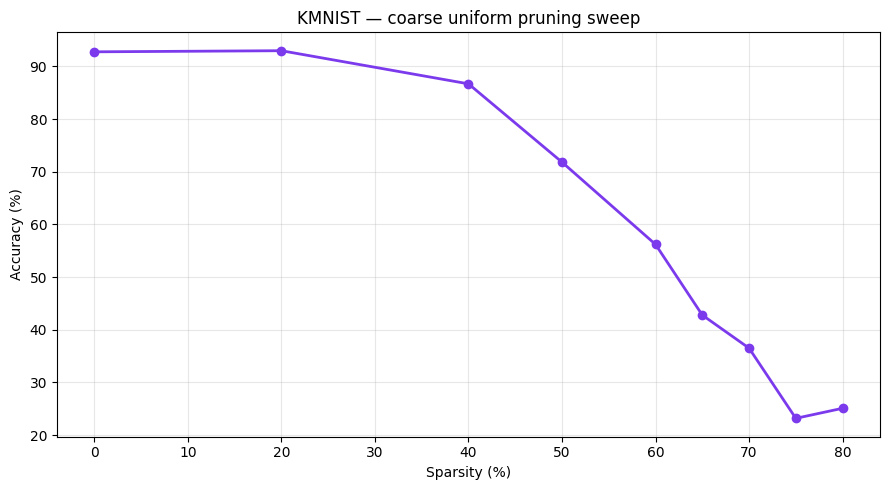

In [15]:
import matplotlib.pyplot as plt

sparsity_kmnist = [0, 20, 40, 50, 60, 65, 70, 75, 80]
accuracy_kmnist = [92.77, 92.98, 86.69, 71.82, 56.20, 42.78, 36.50, 23.17, 25.08]

plt.figure(figsize=(9, 5))
plt.plot(sparsity_kmnist, accuracy_kmnist, marker='o', color='#7C3AED', linewidth=2)
plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('KMNIST — coarse uniform pruning sweep')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmnist_coarse_pruning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

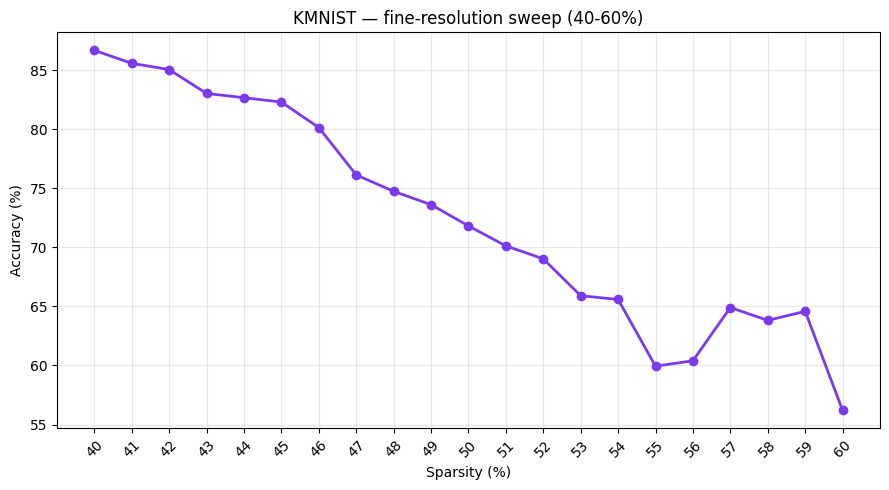

In [17]:
import matplotlib.pyplot as plt

checkpoints_kmnist_finer = [0.40,0.41,0.42,0.43,0.44,0.45,0.46,0.47,0.48,0.49,0.50,
                             0.51,0.52,0.53,0.54,0.55,0.56,0.57,0.58,0.59,0.60]

accuracy_kmnist_finer = [86.69,85.59,85.06,83.04,82.68,82.31,80.15,76.14,74.75,73.62,
                          71.82,70.13,69.03,65.91,65.59,59.94,60.40,64.91,63.82,64.59,56.20]

sparsity_pct_kmnist = [c * 100 for c in checkpoints_kmnist_finer]

plt.figure(figsize=(9, 5))
plt.plot(sparsity_pct_kmnist, accuracy_kmnist_finer, marker='o', color='#7C3AED', linewidth=2)
plt.xticks(sparsity_pct_kmnist, rotation=45)
plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('KMNIST — fine-resolution sweep (40-60%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmnist_finer_pruning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
for amount in [0.60,0.62,0.64,0.66,0.68,0.70,0.72,0.74,0.76,0.78,0.80,0.82,0.84,0.86,0.88,0.90]:
    model = load_fresh_kmnist_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {amount*100:.0f}%", end=" | ")
    evaluate_kmnist(model, test_loader_kmnist)

Sparsity: 60% | KMNIST baseline accuracy: 56.20%
Sparsity: 62% | KMNIST baseline accuracy: 59.51%
Sparsity: 64% | KMNIST baseline accuracy: 51.24%
Sparsity: 66% | KMNIST baseline accuracy: 37.92%
Sparsity: 68% | 

KeyboardInterrupt: 